# Forecasting the Smile

*from claim to design matrix to a scored forecast*

## The question

Can information known at time *t* improve a forecast of the smile at *t+1* beyond the
carry forecast that nothing changes? The core workflow is: define the information boundary,
construct grouped lags, keep fitted preprocessing inside the folds, validate forward through
time, and score every candidate on one shared out-of-fold ledger.

## Volatility project path

For a timed exercise, read [R3.2](#r3-2)–[R3.4](#r3-4), [R3.7](#r3-7),
[R3.9](#r3-9)–[R3.12](#r3-12), [R3.15](#r3-15), [R3.17](#r3-17) and
[R3.22](#r3-22). That is the reusable path from leakage audit to lags, pipeline, baseline,
time split, OOF comparison and final diagnostic. Start with the shorter
[volatility project time-series notebook](volatility_project_02_time_series.ipynb) when the clock is running.

The rough-volatility transformer and Hurst search ([R3.1](#r3-1), [R3.5](#r3-5),
[R3.6](#r3-6), [R3.13](#r3-13), [R3.14](#r3-14)) are domain-specific extensions.
Classification, formal forecast tests, bootstrap intervals and multiplicity correction
([R3.16](#r3-16), [R3.18](#r3-18)–[R3.21](#r3-21)) are valuable after the basic
pipeline is correct; they are not the default first-hour path.

> **Provenance:** stored outputs describe the data and paths printed in that run. Rerun top
> to bottom before treating them as results for the files currently available.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
DATASET      = "smile_90d"
MIN_DTE, MAX_DTE = 7, 60
RESAMPLE_MIN = 5           # thin the 1-minute panel to 5-minute bars
TARGET       = "bf25"      # the curvature; "rr25" for skew, "atm_total_var" for level
HORIZON      = 1           # bars ahead
LAGS         = (1, 2, 3)
ROLL_WINDOWS = (5, 20)
H_PRIOR      = 0.10
HURST_GRID   = (0.05, 0.10, 0.20, 0.40)
N_SPLITS     = 4
EMBARGO_MIN  = (HORIZON + 1) * RESAMPLE_MIN  # strictly beyond the label horizon
N_JOBS       = -1
SEED         = 42
N_BOOT       = 400

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
from rvlab.data import load_smile_panel
from rvlab.features import resample_panel

df = resample_panel(load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE), RESAMPLE_MIN)
print(f"{len(df):,} rows · {df['ts'].nunique():,} timestamps · {df['expiry'].nunique()} expiries")
df.head(3)

76,701 rows · 6,561 timestamps · 100 expiries


,ts,expiry,T,forward,atm_iv,atm_total_var,rr25,bf25,alpha,gamma
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0192,637.225,0.1246,0.0003,-0.0329,0.0033,-0.0542,0.4616
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0219,637.410,0.1278,0.0004,-0.0341,0.0026,-0.0578,0.3394
2,2025-08-07 13:35:00+00:00,2025-08-18,0.0301,637.545,0.1159,0.0004,-0.0339,0.0045,-0.0721,0.6796


## Recipes in this notebook

**From model to design matrix**

| Recipe | What it does |
|---|---|
| [R3.1](#r3-1) | Build the rough features the model suggests |
| [R3.2](#r3-2) | Know the four ways a feature leaks |
| [R3.3](#r3-3) | Lag, difference and roll — grouped, so they mean what you think |
| [R3.4](#r3-4) | Put imputation and scaling inside the pipeline |
| [R3.5](#r3-5) | Write a transformer when a step has fitted state |
| [R3.6](#r3-6) | Make a model parameter tunable instead of assumed |
| [R3.7](#r3-7) | Build the target, and check it is in the future |
| [R3.8](#r3-8) | Combine numeric and categorical branches |

**The benchmark, and validation that respects time**

| Recipe | What it does |
|---|---|
| [R3.9](#r3-9) | Assemble a pipeline that cannot leak |
| [R3.10](#r3-10) | Define the baseline before the model |
| [R3.11](#r3-11) | Choose a splitter that matches the data's structure |
| [R3.12](#r3-12) | Purge and embargo, and see what it costs |
| [R3.13](#r3-13) | Tune hyperparameters inside cross-validation |
| [R3.14](#r3-14) | Search a large space without a full grid |
| [R3.15](#r3-15) | Run the contest — baselines against learned models |
| [R3.16](#r3-16) | Do the same for a classification target |

**Does the model forecast?**

| Recipe | What it does |
|---|---|
| [R3.17](#r3-17) | Score against the baseline, not in absolute terms |
| [R3.18](#r3-18) | Test whether one forecast really beats another |
| [R3.19](#r3-19) | Put an interval on the skill score |
| [R3.20](#r3-20) | Score a classifier without letting accuracy fool you |
| [R3.21](#r3-21) | Correct for how many things you tried |
| [R3.22](#r3-22) | Look at when a model earned its score |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

Most of what separates a real forecast from a leak happens before the model is fitted, in code that looks innocuous.

**Python and pandas**

* **`shift()` without `groupby` reaches across entities.** On a panel it silently takes the
  last row of the previous instrument. Group first, always — the diagnostic below prints how often the two versions disagree.
* **Fit every transformer inside the `Pipeline`.** `StandardScaler().fit(X)` before the split
  leaks the validation distribution into training. The scaler belongs in the pipeline so the
  splitter controls it.
* **Regression CV defaults to unshuffled `KFold`, but it is still not forward-only.** Its
  training folds can contain observations later than validation. Pass an explicit temporal splitter.
* **`n_jobs=-1` copies the payload to each worker.** With a large frame in a closure this is
  memory, not speed. Pass arrays, not frames, into parallel maps.
* **Pandas aligns on the index when you assign.** `df["pred"] = arr` is positional but
  `df["pred"] = other_series` is aligned — mixing the two is how predictions end up attached
  to the wrong rows. Use `.to_numpy()` when you mean positional.

**Analysis**

* **Choose the benchmark before the model.** The active run prints carry's variance explained;
  a model that does not beat it has no result regardless of its R².
* **Purge the label's information horizon.** Backward-looking rolling features do not reach
  into validation; forward labels do. Drop every training row whose label can touch the test.
* **Score against the benchmark, not against zero.** R² against a naive forecast is the
  quantity with meaning; R² against the mean flatters everything.
* **Count your tests.** Thirty grid cells at the 5% level hands you 1.5 false positives before
  any signal exists. Decide the correction before you look.


## From model to design matrix

Turning a structural claim into columns a model can consume, with every transformation checked for the one failure that matters: seeing the future.

## R3.1 · Build the rough features the model suggests
<a id="r3-1"></a>

**Topic** Feature engineering

**Use when** you want a model's structural quantities as columns. Dividing the maturity scaling out of skew and curvature gives `alpha` and `gamma`, which are the model's own coordinates.

**Inputs** `df` with `T`, `atm_iv`, `atm_total_var`, `rr25`, `bf25`.

**Needs** nothing beyond the setup and data cells

**Gotchas** H is a *hyperparameter* here, not a constant. Hard-coding 0.10 bakes in the prior that [R2.9](what_roughness_claims.ipynb#r2-9) rejected. [R3.6](#r3-6) makes it tunable inside cross-validation instead.

**See also** [R2.15](what_roughness_claims.ipynb#r2-15) (what H does to these) · [R3.6](#r3-6) (tuning H properly)

In [4]:
from rvlab.features import add_moneyness_features, add_structural_coefficients

feat = add_moneyness_features(add_structural_coefficients(df, hurst=H_PRIOR))
feat[["T", "dte", "log_T", "atm_iv", "rr25", "bf25", "alpha", "gamma"]].head(3)

,T,dte,log_T,atm_iv,rr25,bf25,alpha,gamma
0,0.0192,7.0,-3.9540,0.1246,-0.0329,0.0033,-0.0542,0.4616
1,0.0219,8.0,-3.8205,0.1278,-0.0341,0.0026,-0.0578,0.3394
2,0.0301,11.0,-3.5020,0.1159,-0.0339,0.0045,-0.0721,0.6796


## R3.2 · Know the four ways a feature leaks
<a id="r3-2"></a>

**Topic** Leakage

**Use when** before building anything. Leakage is not one mistake, it is four, and they need different defences. This is the checklist to run against every column.

**Inputs** nothing — it is a taxonomy.

**Needs** nothing beyond the setup and data cells

**Gotchas** leakage makes a model look *better*, so nothing complains. A validation score that seems too good is the only symptom you get, and by then you have usually built on it.

**See also** [R3.3](#r3-3) (safe lags) · [R3.12](forecasting_the_smile.ipynb#r3-12) (purged CV)

In [5]:
import pandas as pd

leaks = [
    ("Look-ahead", "a feature uses data from after its timestamp",
     "shift() with a negative period; rolling windows centred on t"),
    ("Panel leak", "the same instant appears in train and test",
     "row-wise splits on a panel with many rows per timestamp"),
    ("Preprocessing leak", "a scaler or imputer was fitted on all the data",
     "df.fillna(df.mean()) before splitting"),
    ("Selection leak", "the model was chosen by looking at the test set",
     "sweeping H and reporting the best cell"),
]
pd.DataFrame(leaks, columns=["kind", "what happens", "how it usually gets in"])

,kind,what happens,how it usually gets in
0,Look-ahead,a feature uses data from after its timestamp,shift() with a negative period; rolling window...
1,Panel leak,the same instant appears in train and test,row-wise splits on a panel with many rows per ...
2,Preprocessing leak,a scaler or imputer was fitted on all the data,df.fillna(df.mean()) before splitting
3,Selection leak,the model was chosen by looking at the test set,sweeping H and reporting the best cell


The fourth is the one this project's own README flags about its H4 result: feature, method, H, horizon and regime were all chosen on the same sample, so the reported improvement is hypothesis-generating rather than measured. The scoreboard below and [When a Result Is Real](when_a_result_is_real.ipynb) keep coming back to it.

In [6]:
print("Defences, in order of how often they are skipped:")
for i, d in enumerate(["group the shift", "split on timestamps, not rows",
                       "fit preprocessing inside the pipeline",
                       "hold out a sample you never look at"], 1):
    print(f"  {i}. {d}")

Defences, in order of how often they are skipped:
  1. group the shift
  2. split on timestamps, not rows
  3. fit preprocessing inside the pipeline
  4. hold out a sample you never look at


## R3.3 · Lag, difference and roll — grouped, so they mean what you think
<a id="r3-3"></a>

**Topic** Feature engineering

**Use when** building backward-looking features on a panel. Every one of these must be computed *within* a group, or it crosses contracts.

**Inputs** `df` with `ts` and `expiry`.

**Needs** R3.1 — run those first. This recipe builds on what they define.

**Gotchas** `add_rolling` closes its window **on the right**, so the window ending at t includes t. That is right for describing the state at t and wrong if you meant the w bars *before* t — in which case shift the result by one.

**See also** [R3.2](#r3-2) (leak taxonomy) · [R3.7](#r3-7) (verifying no leak)

In [7]:
from rvlab.features import add_diffs, add_lags, add_rolling

cols = ["atm_iv", "rr25", "bf25", "atm_total_var"]
X = add_rolling(add_diffs(add_lags(feat, cols, LAGS), cols),
                cols, windows=ROLL_WINDOWS, stats=("mean", "std"))
print(f"{len(feat.columns)} columns -> {len(X.columns)} after lags, diffs and rolls")
[c for c in X.columns if c.startswith("bf25")]

13 columns -> 45 after lags, diffs and rolls


['bf25',
 'bf25_lag1',
 'bf25_lag2',
 'bf25_lag3',
 'bf25_d1',
 'bf25_mean5',
 'bf25_std5',
 'bf25_mean20',
 'bf25_std20']

The grouping is not cosmetic. In the panel's natural time-sorted order the row before a given row is a *different expiry at the same instant*, so an ungrouped `shift(1)` is not a lag at all — it is a neighbouring contract.

In [8]:
check = df.sort_values(["ts", "expiry"]).head(3000).copy()
check["grouped"] = check.groupby("expiry", observed=True)["bf25"].shift(1)
check["ungrouped"] = check["bf25"].shift(1)

disagree = (check["grouped"] - check["ungrouped"]).abs() > 1e-12
print(f"the two lags disagree on {disagree.mean():.1%} of rows")

the two lags disagree on 99.5% of rows


Look at what the ungrouped column actually contains. Every row here is the *same timestamp*: the 'lag' has reached sideways across the term structure instead of backwards in time.

In [9]:
check[["ts", "expiry", "bf25", "grouped", "ungrouped"]].head(4)

,ts,expiry,bf25,grouped,ungrouped
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0033,NaN,NaN
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0026,NaN,0.0033
2,2025-08-07 13:35:00+00:00,2025-08-18,0.0045,NaN,0.0026
3,2025-08-07 13:35:00+00:00,2025-08-19,0.0050,NaN,0.0045


## R3.4 · Put imputation and scaling inside the pipeline
<a id="r3-4"></a>

**Topic** Preprocessing

**Use when** always. Any step that *learns* something from data — a median, a quantile, a mean and standard deviation — must be fitted on the training fold only. Inside a `Pipeline`, sklearn guarantees that; outside it, nothing does.

**Inputs** a feature frame with NaNs.

**Needs** R3.1, R3.3 — run those first. This recipe builds on what they define.

**Gotchas** `df.fillna(df.median())` before splitting is the canonical preprocessing leak. It looks harmless because a median is 'just a summary' — but it is a summary that includes the test set.

**See also** [R1.16](the_volatility_surface.ipynb#r1-16) (choosing an imputer) · [R3.9](forecasting_the_smile.ipynb#r3-9) (pipelines)

In [10]:
from rvlab.pipelines import make_regression_pipeline

pipe = make_regression_pipeline("ridge")
print(pipe.named_steps.keys())
pipe

dict_keys(['impute', 'winsor', 'scale', 'model'])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('winsor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

Proof that it is doing what it claims: the imputer's learned medians come from the training rows only, so they differ from the medians of the whole frame.

In [11]:
import numpy as np

cols = ["atm_iv", "rr25", "bf25"]
train, full = X[cols].iloc[:5000], X[cols]
fitted = make_regression_pipeline("ridge").named_steps["impute"].fit(train)

print("median learned on train :", np.round(fitted.statistics_, 5))
print("median of the whole set :", np.round(full.median().to_numpy(), 5))

median learned on train : [ 0.1148 -0.0321  0.0034]
median of the whole set : [ 0.1313 -0.0445  0.0049]


## R3.5 · Write a transformer when a step has fitted state
<a id="r3-5"></a>

**Topic** Preprocessing

**Use when** you need a preprocessing step sklearn does not provide. Implementing `BaseEstimator, TransformerMixin` makes it composable, cloneable, and — crucially — fitted per fold.

**Inputs** `X` with numeric columns.

**Needs** R3.1, R3.3 — run those first. This recipe builds on what they define.

**Gotchas** the giveaway that something *should* be a transformer is the word 'quantile', 'median' or 'mean' in its description. If the step needs to look at data to decide what to do, it has fitted state and belongs in the pipeline.

**See also** [R1.17](the_volatility_surface.ipynb#r1-17) (winsorizing) · [R3.6](#r3-6) (a tunable transformer)

In [12]:
from rvlab.pipelines import Winsorizer

w = Winsorizer(lower=0.01, upper=0.99).fit(X[["rr25", "bf25"]].iloc[:5000])
print("bounds learned on the training slice:")
w.lower_bounds_.to_frame("lower").join(w.upper_bounds_.to_frame("upper")).round(5)

bounds learned on the training slice:


,lower,upper
rr25,-0.0487,-0.0227
bf25,0.0008,0.0073


Because it is a real transformer it composes, and `set_output(transform='pandas')` keeps the column names — which is what makes [R4.1](when_a_result_is_real.ipynb#r4-1)'s interpretability plot readable instead of labelled `x0, x1, x2`.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

demo = Pipeline([("winsor", Winsorizer()), ("scale", RobustScaler())])
demo.set_output(transform="pandas")
demo.fit_transform(X[["rr25", "bf25"]].iloc[:5000]).head(3)

,rr25,bf25
0,-0.1102,-0.1395
60,-0.0929,-0.1796
120,-0.1627,0.7658


## R3.6 · Make a model parameter tunable instead of assumed
<a id="r3-6"></a>

**Topic** Hyperparameters

**Use when** a 'constant' in your model is actually a choice. Wrapping it in a transformer turns it into a hyperparameter that cross-validation can select — scored out of sample, rather than picked by looking at the whole dataset.

**Inputs** `X` with the smile columns.

**Needs** R3.1, R3.3 — run those first. This recipe builds on what they define.

**Gotchas** this is the honest way to sweep H. Choosing the H that looks best on the full sample and then reporting that fit is selection leak — the fourth kind in [R3.2](#r3-2).

**See also** [R3.1](#r3-1) (fixed H) · [R3.13](forecasting_the_smile.ipynb#r3-13) (tuning it in CV)

In [14]:
from rvlab.pipelines import StructuralCoefficients

needed = ["T", "atm_iv", "atm_total_var", "rr25", "bf25"]
out = StructuralCoefficients(hurst=0.05).fit_transform(X[needed])
print("columns added:", [c for c in out.columns if c not in needed])
out[["alpha", "gamma"]].describe().loc[["mean", "std"]].round(4)

columns added: ['alpha', 'gamma']


,alpha,gamma
mean,-0.0932,0.3722
std,0.0386,0.1722


Changing H changes the features, so different H values give genuinely different models — which is exactly why it belongs in the grid rather than in a constant.

In [15]:
import pandas as pd

rows = {h: StructuralCoefficients(hurst=h).fit_transform(X[needed])["gamma"].median()
        for h in (0.05, 0.10, 0.20, 0.40)}
pd.Series(rows, name="median gamma").rename_axis("H").to_frame().round(4)

,median gamma
H,
0.05,0.3633
0.10,0.4883
0.20,0.8725
0.40,2.7913


## R3.7 · Build the target, and check it is in the future
<a id="r3-7"></a>

**Topic** Target construction

**Use when** the last step before modelling. The target is `shift(-horizon)` — the only place a negative shift is correct — and it must be grouped like everything else.

**Inputs** `X`, and `TARGET`/`HORIZON`.

**Needs** R3.1, R3.3 — run those first. This recipe builds on what they define.

**Gotchas** never let a `*_fwd*` column into the feature list. It is the most embarrassing possible leak and it produces an R² near 1.0, which people sometimes report.

**See also** [R3.2](#r3-2) (leak taxonomy) · [R3.10](forecasting_the_smile.ipynb#r3-10) (horizon choice)

In [16]:
from rvlab.features import make_target, supervised_frame

labelled = make_target(X, TARGET, horizon=HORIZON)
target_col = labelled.attrs["target"]

feature_cols = [c for c in labelled.columns
                if c not in {"ts", "expiry", target_col} and "_fwd" not in c
                and labelled[c].dtype.kind == "f"]
print(f"target: {target_col} | {len(feature_cols)} features")

target: bf25_fwd1 | 43 features

> ⚠️ **Leakage:** the `_fwd` filter above is deliberate and load-bearing. Verify rather than trust it — the correlation of any feature with the target should be well below 1.

In [17]:
design, y = supervised_frame(labelled, target_col, [*feature_cols, "ts", "expiry"])
worst = design.select_dtypes("number").corrwith(y).abs().sort_values(ascending=False)
print(f"design matrix {design.shape}")
print(f"highest |correlation| with the target: {worst.iloc[0]:.4f} ({worst.index[0]})")

design matrix (75701, 45)
highest |correlation| with the target: 0.8832 (bf25_mean5)


## R3.8 · Combine numeric and categorical branches
<a id="r3-8"></a>

**Topic** Preprocessing

**Use when** your features are not all numeric. `ColumnTransformer` routes each dtype through its own preprocessing and concatenates the result.

**Inputs** `design` plus a categorical column such as `tenor_bucket`.

**Needs** R3.7 — run those first. This recipe builds on what they define.

**Gotchas** `handle_unknown='ignore'` on the encoder is what stops a category that appears only in the test fold from raising at predict time. Without it a model that trains fine can fail in production on an unseen value.

**See also** [R3.4](#r3-4) (why inside a pipeline) · [R3.9](forecasting_the_smile.ipynb#r3-9) (full pipeline)

In [18]:
from rvlab.features import add_tenor_bucket
from rvlab.pipelines import make_column_transformer

bucketed = add_tenor_bucket(design.assign(T=design["T"]))
numeric = ["atm_iv", "rr25", "bf25", "T"]
ct = make_column_transformer(numeric=numeric, categorical=["tenor_bucket"])

encoded = ct.fit_transform(bucketed[[*numeric, "tenor_bucket"]])
print(f"{len(numeric) + 1} input columns -> {encoded.shape[1]} after one-hot encoding")
encoded.head(3)

5 input columns -> 9 after one-hot encoding


,atm_iv,rr25,bf25,T,tenor_bucket_0-10d,tenor_bucket_10-21d,tenor_bucket_21-35d,tenor_bucket_35-60d,tenor_bucket_60-999d
539,-0.0660,0.7108,-0.3619,-0.3636,1.0,0.0,0.0,0.0,0.0
599,0.0285,0.6379,-0.2727,-0.3636,1.0,0.0,0.0,0.0,0.0
659,-0.0054,0.7093,-0.6825,-0.3636,1.0,0.0,0.0,0.0,0.0


## The benchmark, and validation that respects time

What has to be beaten, and a splitting scheme that will not flatter anything. Both are decided before a model is fitted, which is the only order that works.

Its data cell binds `cols`, `df`, `panel`, `target_col`.

In [19]:
from rvlab.data import load_smile_panel
from rvlab.features import (add_lags, add_rolling, add_structural_coefficients,
                            make_target, resample_panel)

panel = resample_panel(load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE), RESAMPLE_MIN)
cols = ["atm_iv", "rr25", "bf25", "atm_total_var"]
df = make_target(add_rolling(add_lags(add_structural_coefficients(panel), cols, LAGS),
                             cols, windows=ROLL_WINDOWS, stats=("mean", "std")),
                 TARGET, HORIZON)
target_col = df.attrs["target"]
print(f"{df.shape[0]:,} rows · {df.shape[1]} columns · target = {target_col}")

76,701 rows · 39 columns · target = bf25_fwd1


## R3.9 · Assemble a pipeline that cannot leak
<a id="r3-9"></a>

**Topic** Pipelines

**Use when** every supervised model. A `Pipeline` is not tidiness — it is the mechanism that guarantees preprocessing is fitted per fold. Anything you do to the data outside it is outside that guarantee.

**Inputs** a numeric feature frame.

**Needs** nothing beyond the setup and data cells

**Gotchas** `set_output(transform='pandas')` is worth setting always. Without it every step returns a bare array, column names are lost at the first scaler, and [R4.1](when_a_result_is_real.ipynb#r4-1)'s importance plot ends up labelled `x0, x1, x2`.

**See also** [R3.4](forecasting_the_smile.ipynb#r3-4) (why inside) · [R3.13](#r3-13) (tuning it)

In [20]:
from rvlab.features import supervised_frame
from rvlab.pipelines import make_regression_pipeline

features = ["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma",
            "bf25_lag1", "bf25_lag2", "rr25_lag1", "atm_iv_lag1", "bf25_mean5"]
X, y = supervised_frame(df, target_col, [*features, "ts", "expiry"])
print(f"X {X.shape} · y {y.shape}")
make_regression_pipeline("ridge")

X (76401, 14) · y (76401,)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('winsor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

## R3.10 · Define the baseline before the model
<a id="r3-10"></a>

**Topic** Baselines

**Use when** always, and first. A score is meaningless without the number it has to beat. For a time series that is almost always the random walk — predict the current value.

**Inputs** `X` containing the target's current level (here `bf25`), and `y`.

**Needs** R3.9 — run those first. This recipe builds on what they define.

**Gotchas** the baseline must be scored on exactly the rows the model is scored on. Scoring a model on a filtered subset and the baseline on everything is a comparison of two different questions.

**See also** [R3.17](forecasting_the_smile.ipynb#r3-17) (skill scores) · [R3.11](#r3-11) (splitters)

In [21]:
from rvlab.evaluate import rmse
from rvlab.models.baselines import AR1Forecaster, CarryForecaster

carry = CarryForecaster(level_col=TARGET).fit(X, y)
print(f"carry RMSE over the whole sample: {rmse(y, carry.predict(X)):.6f}")
print(f"target standard deviation:        {y.std():.6f}")

carry RMSE over the whole sample: 0.001063
target standard deviation:        0.001969


Carry already explains most of the variance, which is the fact that makes this a hard problem rather than an easy one. The room a model has to work in is the gap between carry's error and zero — and that gap is small.

In [22]:
from rvlab.evaluate import r2

print(f"carry R2 : {r2(y, carry.predict(X)):.4f}")
print(f"AR(1) R2 : {r2(y, AR1Forecaster(level_col=TARGET).fit(X, y).predict(X)):.4f}")

carry R2 : 0.7083
AR(1) R2 : 0.7299


## R3.11 · Choose a splitter that matches the data's structure
<a id="r3-11"></a>

**Topic** Cross-validation

**Use when** any temporal or panel data. Default `KFold` does not shuffle regression rows, but its training folds still include later observations. `TimeSeriesSplit` fixes the direction but still splits *rows*, which on a panel puts the same instant on both sides.

**Inputs** `X` with a `ts` column.

**Needs** R3.9 — run those first. This recipe builds on what they define.

**Gotchas** always print the folds. `describe_folds` shows the actual gap between train and test — seeing `0 days 00:00:00` where you expected 30 minutes is how you discover you passed an int where a `Timedelta` was needed.

**See also** [R3.2](forecasting_the_smile.ipynb#r3-2) (leak taxonomy) · [R3.12](#r3-12) (the embargo)

In [23]:
import pandas as pd
from rvlab.pipelines import GroupTimeSeriesSplit, describe_folds

cv = GroupTimeSeriesSplit(n_splits=N_SPLITS, embargo=pd.Timedelta(minutes=EMBARGO_MIN))
folds = describe_folds(cv, X)
folds

,fold,n_train,n_test,train_end,test_start,gap,overlap
0,0,15203,15464,2025-09-02 13:45:00+00:00,2025-09-02 13:55:00+00:00,0 days 00:10:00,False
1,1,30670,14897,2025-09-25 13:55:00+00:00,2025-09-25 14:05:00+00:00,0 days 00:10:00,False
2,2,45565,14876,2025-10-20 14:05:00+00:00,2025-10-20 14:15:00+00:00,0 days 00:10:00,False
3,3,60441,15916,2025-11-13 16:55:00+00:00,2025-11-13 17:05:00+00:00,0 days 00:10:00,False


Three properties to check every time: `overlap` is False everywhere, `gap` is at least the embargo you asked for, and the training sets grow (an expanding window) rather than jumping around.

In [24]:
print(f"any train/test overlap : {folds['overlap'].any()}")
print(f"smallest gap           : {folds['gap'].min()}")
print(f"training sizes         : {list(folds['n_train'])}")

any train/test overlap : False
smallest gap           : 0 days 00:10:00
training sizes         : [15203, 30670, 45565, 60441]


## R3.12 · Purge and embargo, and see what it costs
<a id="r3-12"></a>

**Topic** Cross-validation

**Use when** labels look forward or observations represent intervals. Purge every training row whose label-information interval can touch the validation period.

**Inputs** `X` with `ts`; the embargo as a `pd.Timedelta`.

**Needs** R3.9 — run those first. This recipe builds on what they define.

**Gotchas** backward-looking rolling features do not consume future validation bars. The relevant span here is the forward label horizon. Because this splitter keeps the boundary timestamp, use a gap strictly longer than that horizon and verify the realised fold spans.

**See also** [R3.11](#r3-11) (splitters) · [R3.3](forecasting_the_smile.ipynb#r3-3) (rolling windows)

In [25]:
import pandas as pd
from rvlab.pipelines import GroupTimeSeriesSplit, describe_folds

rows = []
for minutes in (0, HORIZON * RESAMPLE_MIN, EMBARGO_MIN, 30):
    f = describe_folds(GroupTimeSeriesSplit(n_splits=N_SPLITS,
                                            embargo=pd.Timedelta(minutes=minutes)), X)
    rows.append({"embargo_min": minutes, "median_gap": f["gap"].median(),
                 "total_train_rows": int(f["n_train"].sum())})
pd.DataFrame(rows)

,embargo_min,median_gap,total_train_rows
0,0,0 days 00:05:00,151922
1,5,0 days 00:05:00,151922
2,10,0 days 00:10:00,151879
3,30,0 days 00:30:00,151720


> ⚠️ **Leakage:** a longer embargo throws training data away. That is the trade — and it is a real cost, not a free safety measure. The wrong response is to shorten the embargo because the score looks better; a better score with less purging is exactly what leakage looks like.

In [26]:
label_horizon = HORIZON * RESAMPLE_MIN
print(f"forward label horizon    : {label_horizon} minutes")
print(f"embargo in use           : {EMBARGO_MIN} minutes")
print("strictly separated" if EMBARGO_MIN > label_horizon else "TOO SHORT")

forward label horizon    : 5 minutes
embargo in use           : 10 minutes
strictly separated


## R3.13 · Tune hyperparameters inside cross-validation
<a id="r3-13"></a>

**Topic** Model selection

**Use when** you have a parameter to choose. `GridSearchCV` refits on each fold and scores out of sample, so the chosen value is not the one that happened to fit the whole dataset best.

**Inputs** a pipeline, a grid, and the splitter from [R3.11](#r3-11).

**Needs** R3.9 — run those first. This recipe builds on what they define.

**Gotchas** the grid is where H finally gets chosen honestly. Note the search reports the *best* cell, which is itself an optimistic statistic — [R3.21](forecasting_the_smile.ipynb#r3-21) is about that.

**See also** [R3.6](forecasting_the_smile.ipynb#r3-6) (H as a parameter) · [R3.14](#r3-14) (randomized search)

In [27]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from rvlab.pipelines import (GroupTimeSeriesSplit, StructuralCoefficients,
                             make_regression_pipeline)

cv = GroupTimeSeriesSplit(n_splits=N_SPLITS, embargo=pd.Timedelta(minutes=EMBARGO_MIN))
base = make_regression_pipeline("ridge")
tunable_ridge = Pipeline([("rough", StructuralCoefficients(H_PRIOR)), *base.steps])
tuning_grid = {"rough__hurst": list(HURST_GRID),
               "model__alpha": [0.1, 1.0, 10.0, 100.0]}
search = GridSearchCV(tunable_ridge, tuning_grid, cv=list(cv.split(X)),
                      scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
search.fit(X[features], y)
print(f"best {search.best_params_} | CV RMSE {-search.best_score_:.6f}")

best {'model__alpha': 100.0, 'rough__hurst': 0.4} | CV RMSE 0.000907


The whole search path, not just the winner. A flat curve means the parameter does not matter and the tuning was theatre; a sharp one means it does.

In [28]:
pd.DataFrame(search.cv_results_)[
    ["param_rough__hurst", "param_model__alpha",
     "mean_test_score", "std_test_score"]
].assign(rmse=lambda d: -d["mean_test_score"]).round(6)

,param_rough__hurst,param_model__alpha,mean_test_score,std_test_score,rmse
0,0.05,0.1,-0.0009,6.1000e-05,0.0009
1,0.10,0.1,-0.0009,6.1000e-05,0.0009
2,0.20,0.1,-0.0009,6.1000e-05,0.0009
3,0.40,0.1,-0.0009,6.3000e-05,0.0009
4,0.05,1.0,-0.0009,6.1000e-05,0.0009
5,0.10,1.0,-0.0009,6.1000e-05,0.0009
6,0.20,1.0,-0.0009,6.1000e-05,0.0009
7,0.40,1.0,-0.0009,6.2000e-05,0.0009
8,0.05,10.0,-0.0009,6.1000e-05,0.0009
9,0.10,10.0,-0.0009,6.1000e-05,0.0009


## R3.14 · Search a large space without a full grid
<a id="r3-14"></a>

**Topic** Model selection

**Use when** the grid is too big to enumerate. `RandomizedSearchCV` samples it; `HalvingGridSearchCV` runs a tournament, giving progressively more data to the survivors.

**Inputs** a pipeline and a parameter distribution.

**Needs** R3.9 — run those first. This recipe builds on what they define.

**Gotchas** randomized search with `n_iter` samples finds a near-optimal point far more cheaply than an exhaustive grid once you have more than two or three parameters — the grid's cost is multiplicative, the sample's is not.

**See also** [R3.13](#r3-13) (grid search)

In [29]:
import numpy as np, pandas as pd
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from rvlab.pipelines import GroupTimeSeriesSplit, make_regression_pipeline

cv = GroupTimeSeriesSplit(n_splits=N_SPLITS, embargo=pd.Timedelta(minutes=EMBARGO_MIN))
rnd = RandomizedSearchCV(make_regression_pipeline("elasticnet"),
                         {"model__alpha": loguniform(1e-6, 1e-1),
                          "model__l1_ratio": [0.1, 0.5, 0.9]},
                         n_iter=12, cv=list(cv.split(X)), random_state=SEED,
                         scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
rnd.fit(X[features], y)
print(f"best: {rnd.best_params_} | CV RMSE {-rnd.best_score_:.6f}")

best: {'model__alpha': np.float64(6.025215736203862e-06), 'model__l1_ratio': 0.9} | CV RMSE 0.000905


## R3.15 · Run the contest — baselines against learned models
<a id="r3-15"></a>

**Topic** Model comparison

**Use when** the actual question. Every model gets the same folds, the same rows and the same scoring, and the baselines run in the same loop rather than being quoted from memory.

**Inputs** `X`, `y`, and the splitter.

**Needs** R3.9, R3.13 — run those first. This recipe builds on what they define.

**Gotchas** score on the *concatenated out-of-fold predictions*, not the average of per-fold scores. Folds differ in size and difficulty, and averaging RMSEs across them is not the RMSE of anything.

**See also** [R3.17](forecasting_the_smile.ipynb#r3-17) (reading the table) · [R3.18](forecasting_the_smile.ipynb#r3-18) (is the gap real?)

In [30]:
import numpy as np, pandas as pd
from sklearn.base import clone
from rvlab.models.baselines import (AR1Forecaster, CarryConditionedRough,
                                    CarryForecaster, RoughStructuralForecaster)
from rvlab.pipelines import make_regression_pipeline

models = {
    "carry": CarryForecaster(level_col=TARGET),
    "ar1": AR1Forecaster(level_col=TARGET),
    "rough": RoughStructuralForecaster(target=TARGET, hurst=H_PRIOR),
    "rough_cond_carry": CarryConditionedRough(target=TARGET, hurst=H_PRIOR),
    "ridge": tunable_ridge,
    "hgb": make_regression_pipeline("hgb"),
}
folds = list(cv.split(X))
selected_params = []
print(f"{len(models)} models x {len(folds)} folds")

6 models x 4 folds


Out-of-fold predictions, collected once so every later diagnostic scores the same rows. The scoreboard section below picks up this exact ledger.

In [31]:
oof = {name: np.full(len(X), np.nan) for name in models}
for train_idx, test_idx in folds:
    outer_train = X.iloc[train_idx]
    inner = GroupTimeSeriesSplit(n_splits=max(2, N_SPLITS - 1),
                                 embargo=pd.Timedelta(minutes=EMBARGO_MIN))
    tuned = GridSearchCV(clone(tunable_ridge), tuning_grid,
                         cv=list(inner.split(outer_train)),
                         scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
    tuned.fit(outer_train[features], y.iloc[train_idx])
    selected_params.append(tuned.best_params_)
    for name, model in models.items():
        cols = features if name in ("ridge", "hgb") else X.columns
        fitted = tuned if name == "ridge" else clone(model).fit(
            X.iloc[train_idx][cols], y.iloc[train_idx])
        oof[name][test_idx] = fitted.predict(X.iloc[test_idx][cols])

scored = ~np.isnan(oof["carry"])
print(f"{scored.sum():,} of {len(X):,} rows scored out of fold")
print("nested Ridge selections:", selected_params)

61,153 of 76,401 rows scored out of fold
nested Ridge selections: [{'model__alpha': 0.1, 'rough__hurst': 0.1}, {'model__alpha': 0.1, 'rough__hurst': 0.05}, {'model__alpha': 100.0, 'rough__hurst': 0.4}, {'model__alpha': 100.0, 'rough__hurst': 0.4}]


## R3.16 · Do the same for a classification target
<a id="r3-16"></a>

**Topic** Classification

**Use when** the question is directional rather than numerical: will curvature rise or fall? Same pipeline shape, different metrics — and class imbalance now matters.

**Inputs** `X`, `y`, and the current level to measure the move from.

**Needs** R3.9, R3.13, R3.15 — run those first. This recipe builds on what they define.

**Gotchas** accuracy is the wrong metric the moment classes are unbalanced: predicting the majority class always can score well and be useless. ROC-AUC and average precision are threshold-free and do not have that failure mode.

**See also** [R3.20](forecasting_the_smile.ipynb#r3-20) (classification metrics) · [R3.15](#r3-15) (the regression contest)

In [32]:
import numpy as np
from sklearn.base import clone
from rvlab.pipelines import make_classification_pipeline

direction = (y.to_numpy() > X[TARGET].to_numpy()).astype(int)
print(f"base rate (curvature rises): {direction.mean():.3f}")

clf = make_classification_pipeline("logistic")
proba = np.full(len(X), np.nan)
for train_idx, test_idx in folds:
    fitted = clone(clf).fit(X.iloc[train_idx][features], direction[train_idx])
    proba[test_idx] = fitted.predict_proba(X.iloc[test_idx][features])[:, 1]

print(f"{np.isfinite(proba).sum():,} out-of-fold probabilities")

base rate (curvature rises): 0.499


61,153 out-of-fold probabilities


A first look at whether there is any directional signal at all. [R3.20](#r3-20) scores this properly; here we only check the pipeline runs and the probabilities are not degenerate.

In [33]:
from sklearn.metrics import roc_auc_score

ok = np.isfinite(proba)
print(f"out-of-fold ROC-AUC: {roc_auc_score(direction[ok], proba[ok]):.4f}  (0.5 = no signal)")
print(f"predicted probability range: {proba[ok].min():.3f} to {proba[ok].max():.3f}")

out-of-fold ROC-AUC: 0.7135  (0.5 = no signal)
predicted probability range: 0.000 to 1.000


## Does the model forecast?

Scoring, and the three ways a scoreboard misleads: the wrong metric, the wrong baseline, and too many tests.

Its data cell reloads the section's source frame. [R3.17](#r3-17) then materialises `df` from the single nested out-of-fold ledger produced by [R3.15](#r3-15); it never fits that contest a second time.

In [34]:
from rvlab.data import load_smile_panel
from rvlab.features import (add_lags, add_rolling, add_structural_coefficients,
                            make_target, resample_panel)

panel = resample_panel(load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE),
                         RESAMPLE_MIN)
cols = ["atm_iv", "rr25", "bf25", "atm_total_var"]
df = make_target(add_rolling(add_lags(add_structural_coefficients(panel), cols, LAGS),
                             cols, windows=ROLL_WINDOWS, stats=("mean", "std")),
                 TARGET, HORIZON)
target_col = df.attrs["target"]
print(f"source frame reloaded: {df.shape[0]:,} rows; R3.15 owns the sole OOF fit")

source frame reloaded: 76,701 rows; R3.15 owns the sole OOF fit


## R3.17 · Score against the baseline, not in absolute terms
<a id="r3-17"></a>

**Topic** Metrics

**Use when** reporting any forecast result. `skill = 1 - RMSE(model)/RMSE(baseline)`: positive beats the baseline, zero ties it, negative loses. Absolute RMSE on a quantity of order 1e-3 is uninterpretable.

**Inputs** `df` with `y_true`, `y_prev` and one column per model.

**Needs** R3.15 — run that first. This recipe scores its single nested OOF ledger.

**Gotchas** score every model on the same rows. A model that quietly drops the observations it finds hard will report a lovely RMSE for a different question.

**See also** [R3.18](#r3-18) (is the gap real?) · [R3.10](forecasting_the_smile.ipynb#r3-10) (defining the baseline)

In [35]:
import numpy as np, pandas as pd
from rvlab.evaluate import regression_report

mask = scored.copy()
assert len(mask) == len(X) == len(y)
assert all(len(pred) == len(mask) for pred in oof.values())
df = pd.DataFrame({"y_true": y.to_numpy()[mask],
                   "y_prev": X[TARGET].to_numpy()[mask],
                   **{name: pred[mask] for name, pred in oof.items()}})
names = [c for c in df.columns if c not in ("y_true", "y_prev")]
report = regression_report(df["y_true"], {n: df[n] for n in names},
                           baseline="carry", y_prev=df["y_prev"])
print(f"{len(df):,} rows from the R3.15 ledger · Ridge selections {selected_params}")
report.round(5)

61,153 rows from the R3.15 ledger · Ridge selections [{'model__alpha': 0.1, 'rough__hurst': 0.1}, {'model__alpha': 0.1, 'rough__hurst': 0.05}, {'model__alpha': 100.0, 'rough__hurst': 0.4}, {'model__alpha': 100.0, 'rough__hurst': 0.4}]


,rmse,mae,bias,r2,skill_vs_carry,dir_acc
model,,,,,,
ridge,0.0009,0.0005,-1.0000e-05,0.7684,0.1510,0.6537
hgb,0.0009,0.0006,3.0000e-05,0.7544,0.1257,0.6456
ar1,0.0010,0.0006,2.0000e-05,0.7029,0.0384,0.5546
carry,0.0011,0.0006,0.0000e+00,0.6787,0.0000,NaN
rough_cond_carry,0.0011,0.0006,2.3000e-04,0.6772,-0.0023,0.5505
rough,0.0030,0.0022,1.6400e-03,-1.5292,-1.8056,0.5474


The table is the verdict for the active run: the sign and magnitude of each skill value say whether and by how much it beat carry. Any research-registry entry is a separate historical run and should only be compared after checking provenance.\n\nCarry's directional accuracy is `NaN` on purpose: carry predicts *no* move, so it makes no directional call at all. Scoring that as 0% would flatter every other model.

In [36]:
from rvlab.data import describe_provenance

skill = report[f"skill_vs_carry"]
rough_bias = report.loc["rough", "bias"]
rough_verdict = "beats" if skill["rough"] > 0 else "loses to"
print(describe_provenance(panel))
print(f"raw rough {rough_verdict} carry: skill {skill['rough']:+.4f}, bias {rough_bias:+.3e}")
print(f"best model               : {skill.idxmax()} ({skill.max():+.4f})")

smile_90d: 380,857 rows from /Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl | 2025-08-07 13:35:00+00:00 -> 2025-12-12 19:55:00+00:00
raw rough loses to carry: skill -1.8056, bias +1.636e-03
best model               : ridge (+0.1510)


## R3.18 · Test whether one forecast really beats another
<a id="r3-18"></a>

**Topic** Significance

**Use when** two models differ in RMSE and you need to know if that is signal. Diebold-Mariano tests equal predictive accuracy using a HAC variance, which is what serial correlation requires.

**Inputs** `y_true` and two prediction arrays.

**Needs** R3.17 — run those first. This recipe builds on what they define.

**Gotchas** a paired t-test on forecast errors assumes independent observations. Consecutive 5-minute smile errors are strongly correlated, so a t-test will report significance that is not there. DM exists precisely for this.

**See also** [R3.19](#r3-19) (bootstrap intervals) · [R3.21](#r3-21) (multiplicity)

In [37]:
import pandas as pd
from rvlab.evaluate import diebold_mariano

rows = []
for name in [n for n in names if n != "carry"]:
    res = diebold_mariano(df["y_true"], df[name], df["carry"], horizon=1)
    rows.append({"model": name, "DM": round(res.statistic, 2),
                 "p_value": round(res.p_value, 6), "favours": res.favours})
pd.DataFrame(rows).set_index("model")

,DM,p_value,favours
model,,,
ar1,-13.21,0.000,model A
rough,104.17,0.000,model B
rough_cond_carry,0.51,0.607,neither (not significant at 5%)
ridge,-11.56,0.000,model A
hgb,-9.37,0.000,model A


Negative DM favours the model, positive favours carry. The ledger size is printed above; whatever that size, the *sign* and effect size belong beside the p-value.\n\n> ⚠️ **Sample size:** significance is not importance. A statistically detectable RMSE improvement can still be economically tiny, and it still has to survive the transaction-cost test in [R4.17](when_a_result_is_real.ipynb#r4-17).

In [38]:
from rvlab.evaluate import paired_permutation_test

best = report[f"skill_vs_carry"].idxmax()
perm = paired_permutation_test(df["y_true"], df[best], df["carry"], n_perm=500, seed=SEED)
print(f"{best} vs carry — permutation p = {perm['p_value']:.4f} "
      f"(DM said {diebold_mariano(df['y_true'], df[best], df['carry']).p_value:.4f})")

ridge vs carry — permutation p = 0.0000 (DM said 0.0000)


## R3.19 · Put an interval on the skill score
<a id="r3-19"></a>

**Topic** Inference

**Use when** a point estimate of skill is not enough. The block bootstrap gives a confidence interval that respects the serial dependence in the error series.

**Inputs** `df`, and a model to evaluate.

**Needs** R3.17, R3.18 — run those first. This recipe builds on what they define.

**Gotchas** bootstrap the *loss differences*, not the two RMSEs separately. The models are scored on the same rows, so the errors are paired and the paired difference has far less variance than either series alone.

**See also** [R3.18](#r3-18) (DM) · [R2.13](what_roughness_claims.ipynb#r2-13) (the same tool on slopes)

In [39]:
import numpy as np, pandas as pd
from rvlab.evaluate import block_bootstrap_ci

rows = []
for name in [n for n in names if n != "carry"]:
    d = (df["y_true"] - df["carry"])**2 - (df["y_true"] - df[name])**2   # >0 = model wins
    ci = block_bootstrap_ci(d, n_boot=N_BOOT, seed=SEED)
    rows.append({"model": name, "mean_loss_gain": f"{ci['point']:+.3e}",
                 "ci_lo": f"{ci['lo']:+.3e}", "ci_hi": f"{ci['hi']:+.3e}",
                 "excludes_zero": ci["excludes_zero"]})
pd.DataFrame(rows).set_index("model")

,mean_loss_gain,ci_lo,ci_hi,excludes_zero
model,,,,
ar1,+8.734e-08,+7.147e-08,+1.054e-07,True
rough,-7.961e-06,-8.669e-06,-7.273e-06,True
rough_cond_carry,-5.279e-09,-3.252e-08,+2.172e-08,False
ridge,+3.235e-07,+2.700e-07,+3.823e-07,True
hgb,+2.729e-07,+2.170e-07,+3.360e-07,True


An interval excluding zero means the model beats carry more reliably than chance. It is worth checking how much the block structure actually mattered, rather than assuming it was decisive.

In [40]:
d = (df["y_true"] - df["carry"])**2 - (df["y_true"] - df[best])**2
blk = block_bootstrap_ci(d, n_boot=N_BOOT, seed=SEED)
iid = block_bootstrap_ci(d, block_size=1, n_boot=N_BOOT, seed=SEED)
print(f"block CI width {blk['hi']-blk['lo']:.3e}  (b = {blk['block_size']})")
print(f"iid   CI width {iid['hi']-iid['lo']:.3e}")
print(f"ratio {(blk['hi']-blk['lo']) / (iid['hi']-iid['lo']):.3f}")

block CI width 1.123e-07  (b = 39)
iid   CI width 1.110e-07
ratio 1.012


The block interval is not guaranteed to be wider than the IID interval in a finite bootstrap: its width depends on the sign and strength of dependence in the **paired loss difference**. Pairing cancels the common component both models share, so inspect the width ratio above and the two autocorrelations below rather than assuming the direction.

In [41]:
import pandas as pd

ac = lambda v: pd.Series(v).autocorr(lag=1)
print(f"lag-1 autocorrelation of carry's squared error : {ac((df['y_true']-df['carry'])**2):.3f}")
print(f"lag-1 autocorrelation of the paired difference : {ac(d):.3f}")

lag-1 autocorrelation of carry's squared error : 0.420
lag-1 autocorrelation of the paired difference : 0.006


## R3.20 · Score a classifier without letting accuracy fool you
<a id="r3-20"></a>

**Topic** Classification metrics

**Use when** the target is a class. Accuracy is misleading whenever classes are unbalanced; ROC-AUC and average precision are threshold-free, and the Brier score measures whether the probabilities themselves are honest.

**Inputs** true labels and predicted probabilities.

**Needs** R3.15 — run that first. This recipe reuses its splitter and design matrix.

**Gotchas** a model can have excellent ROC-AUC and badly calibrated probabilities — good at *ranking*, wrong about *magnitude*. If you will act on the probability (position sizing, say), check calibration, not just AUC.

**See also** [R3.16](forecasting_the_smile.ipynb#r3-16) (fitting it) · [R3.17](#r3-17) (regression metrics)

In [42]:
import numpy as np
from sklearn.base import clone
from rvlab.pipelines import make_classification_pipeline

direction = (y.to_numpy() > X[TARGET].to_numpy()).astype(int)
proba = np.full(len(X), np.nan)
for tr, te in cv.split(X):
    fitted = clone(make_classification_pipeline("logistic")).fit(
        X.iloc[tr][features], direction[tr])
    proba[te] = fitted.predict_proba(X.iloc[te][features])[:, 1]

ok = np.isfinite(proba)
print(f"base rate {direction[ok].mean():.3f} · {ok.sum():,} scored rows")

base rate 0.501 · 61,153 scored rows


A naive 'always predict the majority class' model has accuracy `max(p, 1-p)`, the majority-class share; the printed base rate `p` is specifically the positive-class share. It carries no information, so that is the row to compare against.

In [43]:
from rvlab.evaluate import classification_report_table

majority = np.full(ok.sum(), float(direction[ok].mean()))
classification_report_table(direction[ok],
                            {"logistic": proba[ok], "always_majority": majority}).round(4)

,accuracy,balanced_acc,roc_auc,avg_precision,brier,base_rate
model,,,,,,
logistic,0.6610,0.661,0.7135,0.6976,0.2186,0.5005
always_majority,0.5005,0.500,0.5000,0.5005,0.2500,0.5005


## R3.21 · Correct for how many things you tried
<a id="r3-21"></a>

**Topic** Multiplicity

**Use when** you tested more than one hypothesis — which is always. Testing 30 cells at 5% produces about 1.5 false passes even when nothing is real. Benjamini-Hochberg controls the expected share of false discoveries among your rejections.

**Inputs** a collection of p-values from a family of tests.

**Needs** R3.17 — run those first. This recipe builds on what they define.

**Gotchas** BH controls a declared family of tests; it cannot repair an adaptively enlarged search over features, methods, horizons and regimes. Only a genuinely untouched future block can validate choices made on the development sample.

**See also** [R4.11](when_a_result_is_real.ipynb#r4-11) (on a real sweep) · [R3.18](#r3-18) (individual tests)

In [44]:
import numpy as np, pandas as pd
from rvlab.evaluate import benjamini_hochberg, bonferroni, diebold_mariano

p_values = [diebold_mariano(df["y_true"], df[n], df["carry"]).p_value
            for n in names if n != "carry"]
tested = [n for n in names if n != "carry"]

pd.DataFrame({"model": tested, "p_value": np.round(p_values, 6),
              "bh_reject": benjamini_hochberg(p_values)["reject"].sort_index().to_numpy(),
              "bonferroni_reject": bonferroni(p_values)["reject"].sort_index().to_numpy()})

,model,p_value,bh_reject,bonferroni_reject
0,ar1,0.000,True,True
1,rough,0.000,True,True
2,rough_cond_carry,0.607,False,False
3,ridge,0.000,True,True
4,hgb,0.000,True,True


With five comparisons the correction barely bites. The demonstration that matters is what happens under the **null**, when nothing real is there at all — which is the situation a 30-cell parameter sweep is closest to. One draw of 30 p-values is itself noisy, so average over many replications.

In [45]:
rng = np.random.default_rng(SEED)
raw, bh, bonf = [], [], []
for _ in range(400):
    null_p = rng.uniform(0, 1, 30)
    raw.append((null_p < 0.05).sum())
    bh.append(benjamini_hochberg(null_p)["reject"].sum())
    bonf.append(bonferroni(null_p)["reject"].sum())

print("30 tests of pure noise, averaged over 400 replications (alpha = 0.05):")
print(f"  uncorrected 'significant' : {np.mean(raw):.2f} per sweep")
print(f"  after Benjamini-Hochberg  : {np.mean(bh):.2f}")
print(f"  after Bonferroni          : {np.mean(bonf):.2f}")

30 tests of pure noise, averaged over 400 replications (alpha = 0.05):
  uncorrected 'significant' : 1.51 per sweep
  after Benjamini-Hochberg  : 0.07
  after Bonferroni          : 0.06


Under the null, an uncorrected 30-cell sweep yields about **1.5 spurious passes on average**, not in every run. The next line reports the separate probability of seeing at least one.

In [46]:
print(f"at least one spurious pass in an uncorrected 30-cell sweep: "
      f"{np.mean(np.array(raw) > 0):.1%} of the time")

at least one spurious pass in an uncorrected 30-cell sweep: 78.0% of the time


## R3.22 · Look at when a model earned its score
<a id="r3-22"></a>

**Topic** Diagnostics

**Use when** aggregate metrics hide timing. The cumulative squared-error curve shows whether a model won steadily or won once, in one episode, and coasted.

**Inputs** `df` with `y_true` and the prediction columns.

**Needs** R3.17 — run that first. This recipe visualises the same scored ledger.

**Gotchas** a model whose cumulative curve is flat against the baseline for most of the sample and then drops sharply did not find a persistent effect. It found one event.

**See also** [R3.17](#r3-17) (aggregate scores) · [R4.12](when_a_result_is_real.ipynb#r4-12) (regime conditioning)

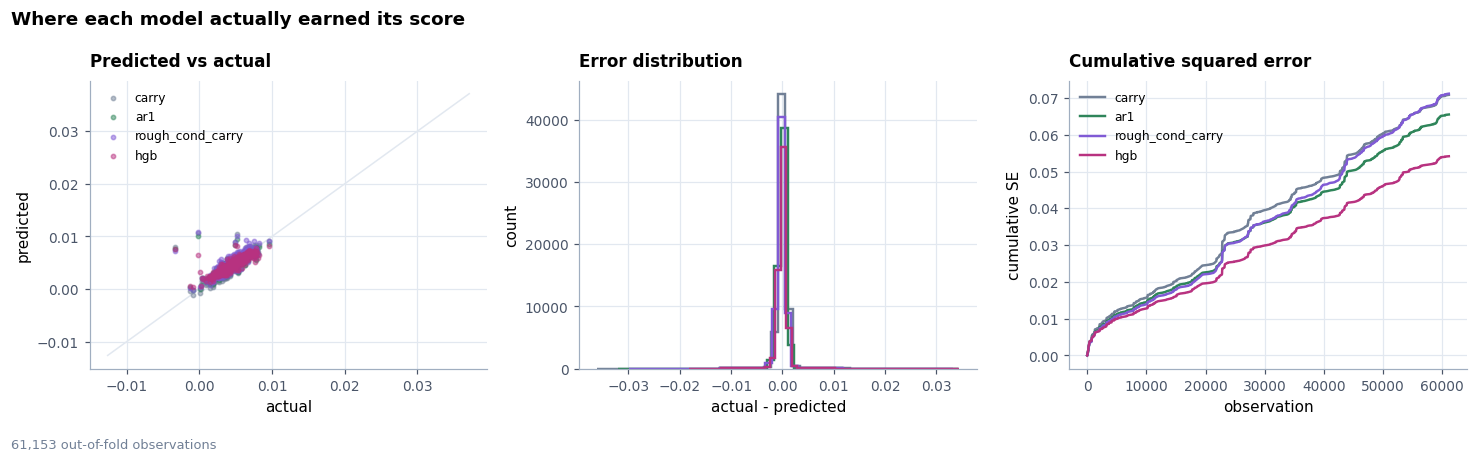

In [47]:
from rvlab.plotting import forecast_diagnostics

shown = ["carry", "ar1", "rough_cond_carry", "hgb"]
forecast_diagnostics(df["y_true"], {n: df[n] for n in shown}, baseline="carry",
                     title="Where each model actually earned its score",
                     note=f"{len(df):,} out-of-fold observations");

The raw rough forecast is left off that chart so the competitive traces remain readable. The exact RMSE ratio, rather than an order-of-magnitude label, is printed below:

In [48]:
import numpy as np
from rvlab.evaluate import rmse

rough_ratio = rmse(df["y_true"], df["rough"]) / rmse(df["y_true"], df["carry"])
for n in ["carry", "rough", "rough_cond_carry"]:
    print(f"  {n:18s} RMSE {rmse(df['y_true'], df[n]):.6f}  "
          f"bias {np.mean(df[n] - df['y_true']):+.2e}")
print(f"  rough / carry RMSE ratio: {rough_ratio:.2f}x")

  carry              RMSE 0.001076  bias +2.47e-06
  rough              RMSE 0.003020  bias +1.64e-03
  rough_cond_carry   RMSE 0.001079  bias +2.29e-04
  rough / carry RMSE ratio: 2.81x


## Verdict & what carries forward

The reusable result is the workflow, not a fixed score:

* build targets and grouped historical features from the stated information set;
* fit imputation, clipping and scaling inside each training fold;
* compare every candidate with carry on the same forward OOF observations; and
* let the active score table and its printed provenance determine the conclusion.

Selection made after viewing the full sample remains a source of optimism that a pipeline
cannot repair. Use [When a Result Is Real](when_a_result_is_real.ipynb) for formal inference
and robustness only after the core comparison is stable.